## CAN ID Cross-File Validation

The benign EDA was built from a single file of about ten million messages. 

- Do the twelve files use the same CAN IDs, that is, do they share
the same *vocabulary*.
- How much more *data* do the twelve files give us, since more
data is the main benefit for the pretraining step.
- Third, even if the set of IDs is the same, does the *way* each ID is used change from one file to another.
- Fourth, which attacks can be spotted just by looking at the CAN IDs, because this last question is what tells us whether a simple rule on IDs would be enough or whether we really need a model
that looks at the payload and the timing.

In [1]:
import sys
from pathlib import Path

import json5
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path("../src").resolve()))
from analyse_attack_file import analyse_attack_file
from analyse_benign_file import analyse_benign_file


In [2]:
BASE = Path("/Users/anita/Documents/TFM/SSL_CyberSecurity")

ATTACK_DIR = BASE / "Attack" / "Real_attacks"
METADATA_PATH = BASE / "Attacks_metadata.json"

In [3]:
benign_folders = sorted(BASE.glob("Benign*"))

benign_files = []

for folder in benign_folders:
    for log_file in folder.rglob("*.log"):
        benign_files.append(log_file)

benign_files = sorted(benign_files)

print("Benign files found: ", len(benign_files))


Benign files found:  12


### Analysis of the benign files 

In [4]:
benign_results = []

benign_union = set()
benign_intersection = None

for benign_file in benign_files:

    file_result = analyse_benign_file(benign_file)

    benign_results.append(file_result)

    file_can_ids = file_result["can_ids"]

    benign_union.update(file_can_ids)

    if benign_intersection is None:

        benign_intersection = file_can_ids.copy()

    else:

        benign_intersection.intersection_update(file_can_ids)

benign_summary_rows = []

for file_result in benign_results:
    benign_summary_rows.append({
        "file": file_result["file"],
        "messages": file_result["message_count"],
        "unique_ids": len(file_result["can_ids"]),
        "duration_s": round(file_result["duration"], 1),
        "messages_per_second": round(file_result["message_rate"], 1),
    })

benign_summary = pd.DataFrame(benign_summary_rows)
benign_summary


,file,messages,unique_ids,duration_s,messages_per_second
0,Benign_day1_file2.log,10000000,56,5337.0,1873.7
1,Benign_day1_file3.log,8494995,56,4574.5,1857.0
2,Benign_day1_file4.log,10000000,56,6547.4,1527.3
3,Benign_day1_file6.log,589705,56,374.1,1576.4
4,Benign_day2_file1.log,10110000,56,5305.1,1905.7
5,Benign_day3_file1.log,9807445,56,5170.9,1896.7
6,Benign_day1_file1.log,10000000,56,5281.8,1893.3
7,Benign_day2_file2.log,10094091,56,5916.0,1706.2
8,Benign_day5_file1.log,10435392,56,5883.8,1773.6
9,Benign_day6_file1.log,10276962,56,6468.8,1588.7


The table shows that all 12 benign files contain the same 56 IDs, showing that the vehicle's CAN ID vocabulary is stable across the recordings. However, the files vary in duration, number of messages and overall message rate, which ranges from approximately 1,527 to 1,906 messages per second. One file is also much shorter than the others, so it provides less evidence about long term behaviour. For the model, the table shows that CAN ID presence is highly consistent, while traffic intensity naturally changes between recordings, therefore, message rate alone should not be interpreted as an attack. 

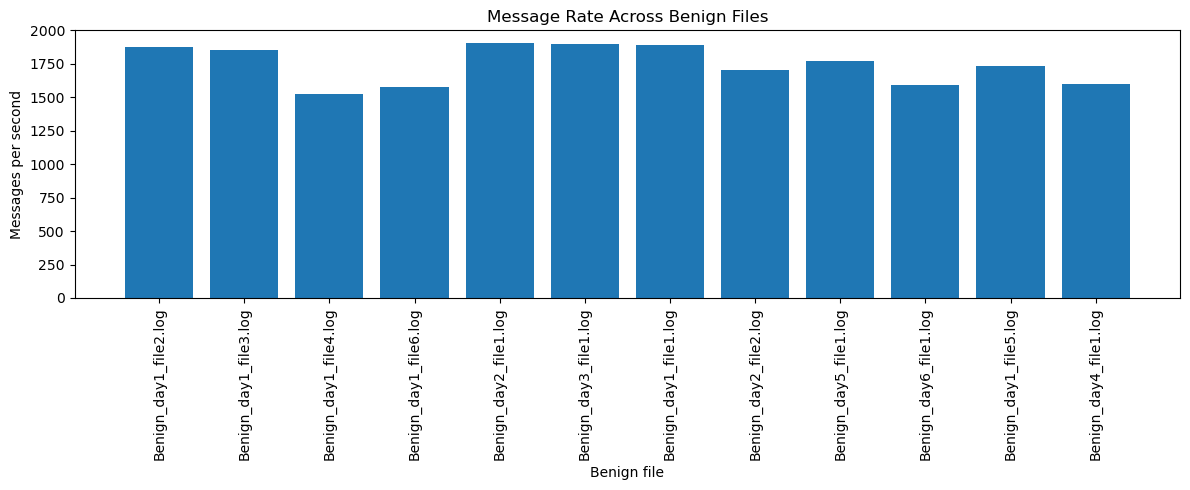

In [5]:
benign_file_names = []
benign_message_rates = []

for file_result in benign_results:

    benign_file_names.append(file_result["file"])
    benign_message_rates.append(file_result["message_rate"])

plt.figure(figsize=(12, 5))

plt.bar(benign_file_names, benign_message_rates)

plt.xlabel("Benign file")
plt.ylabel("Messages per second")
plt.title("Message Rate Across Benign Files")
plt.ylim(bottom=0)

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


Some messages operate close to 1,900 messages per second, while others remain near 1,500 - 1,600, which is part of normal vehicle behaviour. Including all files during SSL pretraining is useful because it exposes the encoder to this normal variation and reduces the risk of treating a different driving or recording condition as malicious. 

#### Data Volume Across Files

The benign EDA used a single ~10M-message file. Self-supervised pretraining benefits mainly
from raw volume (more windows), so this quantifies how much more data the 12 files give.

In [6]:
# 12 files vs the single-file benign baseline used in the EDA
single_file_baseline = 10_000_000
total_messages = sum(r["message_count"] for r in benign_results)
total_duration_h = sum(r["duration"] for r in benign_results) / 3600

print(f"Benign files:            {len(benign_results)}")
print(f"Total benign messages:   {total_messages:,}")
print(f"Total benign duration:   {total_duration_h:.1f} hours")
print(f"Single-file baseline:    {single_file_baseline:,}")
print(f"Volume gain:             {total_messages / single_file_baseline:.1f}x more messages")


Benign files:            12
Total benign messages:   106,479,422
Total benign duration:   16.9 hours
Single-file baseline:    10,000,000
Volume gain:             10.6x more messages


The 12 files provide approximately 106.5 million benign messages covering 16.9 hours, which is about 10.6x more data than the single 10 million message file previously analysed. However, greater volume does not automatically mean greater behavioural diversity, especially because all files still use the same 56 CAN IDs. 

#### CAN IDs Message Frequency Across Files

In [8]:
rate_rows = []

for can_id in sorted(benign_union):

    rates_across_files = []

    for file_result in benign_results:
        id_count = file_result["id_counts"][can_id]
        rates_across_files.append(id_count / file_result["duration"])

    min_rate = min(rates_across_files)
    max_rate = max(rates_across_files)

    rate_rows.append({
        "can_id": can_id,
        "min_rate": round(min_rate, 2),
        "max_rate": round(max_rate, 2),
        "spread_percent": round((max_rate - min_rate) / min_rate * 100, 1),
    })

rate_table = pd.DataFrame(rate_rows).sort_values("spread_percent", ascending=False)
rate_table.head(10)


,can_id,min_rate,max_rate,spread_percent
39,52A,6.35,9.08,43.1
54,5E3,0.76,1.00,31.3
28,4A2,1.52,2.00,31.2
15,389,38.09,49.99,31.2
48,593,3.81,5.00,31.2
34,50A,3.81,5.00,31.2
33,507,7.62,10.00,31.2
24,47F,38.12,50.00,31.2
20,420,38.09,49.99,31.2
17,394,38.12,50.00,31.2


As we can see on the table, CAN ID **52A** ranges from 6.35 to 9.08 messages per second, producing the largest relative spread of 43.1%. Compared to the other IDs which all have approx around 30% spread. This shows that even regularly occurring CAN IDs do not always transmit at an identical rate, so the model must tolerate normal frequency changes. The percentage should still be interpreted carefully because a small absolute change can appear large for low frequency IDs, and minimum and maximum values may be influenced by only one file. 

In [9]:
with open(METADATA_PATH) as f:
    attack_metadata = json5.load(f)

attack_log_names = {
    "DoS": "DoS_attack",
    "Steering Angle Spoofing": "Steering_angle_attack",
    "Brake Warning Spoofing": "Brake_warning_attack",
    "Power Steering Spoofing": "Power_steering_attack",
    "Min Speedometer Spoofing": "Min_speedometer_attack_1",
    "Random-ID Fuzzing": "Fuzzing_random_IDs",
    "Valid-ID Fuzzing": "Fuzzing_valid_IDs",
    "EMS Replay": "EMS_replay_attack",
    "Steering Angle Replay": "Steering_angle_replay",
}

attack_files = {}

for attack_name, log_name in attack_log_names.items():

    start_time, end_time = attack_metadata[log_name]["injection_interval"]

    attack_files[attack_name] = {
        "file": ATTACK_DIR / f"{log_name}.log",
        "start_time": start_time,
        "end_time": end_time,
    }


In [10]:
attack_results = []
attack_summary_rows = []

for attack_name in attack_files:
    attack_information = attack_files[attack_name]

    attack_result = analyse_attack_file(
        attack_information["file"],
        attack_information["start_time"],
        attack_information["end_time"],
    )
    attack_result["attack"] = attack_name
    attack_results.append(attack_result)

    file_can_ids = attack_result["complete_file_can_ids"]

    attack_summary_rows.append({
        "attack": attack_name,
        "unique_ids": len(file_can_ids),
        "new_ids": len(file_can_ids - benign_union),
        "missing_ids": len(benign_union - file_can_ids),
        "duration_s": round(attack_result["duration"], 1),
    })

attack_summary = pd.DataFrame(attack_summary_rows)
print(attack_summary.to_string(index=False))

detectable = int((attack_summary["new_ids"] > 0).sum())
total = len(attack_summary)
print(f"\n{detectable} of {total} attacks add new CAN IDs; the other {total - detectable} reuse valid IDs and cannot be caught by an ID check.")


                  attack  unique_ids  new_ids  missing_ids  duration_s
                     DoS          55        1            2       173.9
 Steering Angle Spoofing          56        0            0       190.3
  Brake Warning Spoofing          56        0            0       302.4
 Power Steering Spoofing          56        0            0       187.5
Min Speedometer Spoofing          54        0            2       283.4
       Random-ID Fuzzing         646      590            0       377.6
        Valid-ID Fuzzing          56        0            0       134.0
              EMS Replay          56        0            0       166.4
   Steering Angle Replay          56        0            0       243.8

2 of 9 attacks add new CAN IDs; the other 7 reuse valid IDs and cannot be caught by an ID check.


Only Dos and Random Fuzzing files introduce CAN IDs that are absent from the 56 benign IDs. Random Fuzzing adding 590 new IDs, while the other seven attacks use only valid vehicle IDs. However the missing ID values should not be treated as direct attack indicators because they are calculated over the complete files and may simply reflect recording duration or normal IDs that did not occur during a shorter recording.

### Random Fuzzing Analysis

In [11]:
for attack_result in attack_results:
    if attack_result["attack"] == "Random-ID Fuzzing":

        new_ids = attack_result["attack_interval_can_ids"] - benign_union
        new_id_values = sorted(int(can_id, 16) for can_id in new_ids)

        lowest = new_id_values[0]
        highest = new_id_values[-1]
        span = highest - lowest + 1

        print(f"New IDs injected:  {len(new_id_values)}")
        print(f"Lowest / highest:  {lowest:03X} / {highest:03X}")
        print(f"Coverage of that span: {len(new_id_values)} of {span} possible IDs")


New IDs injected:  590
Lowest / highest:  000 / 255
Coverage of that span: 590 of 598 possible IDs


Random-ID Fuzzing introduces 590 previously unseen CAN IDs between hexadecimal 000 and 255, covering 590 of the 598 possible values in that range. This indicates a broad and nearly continuous injection pattern rather than a small number of carefully selected IDs. It should therefore be easy to detect through CAN ID novelty alone, although this makes it less representative of the more difficult attacks that reuse valid IDs.

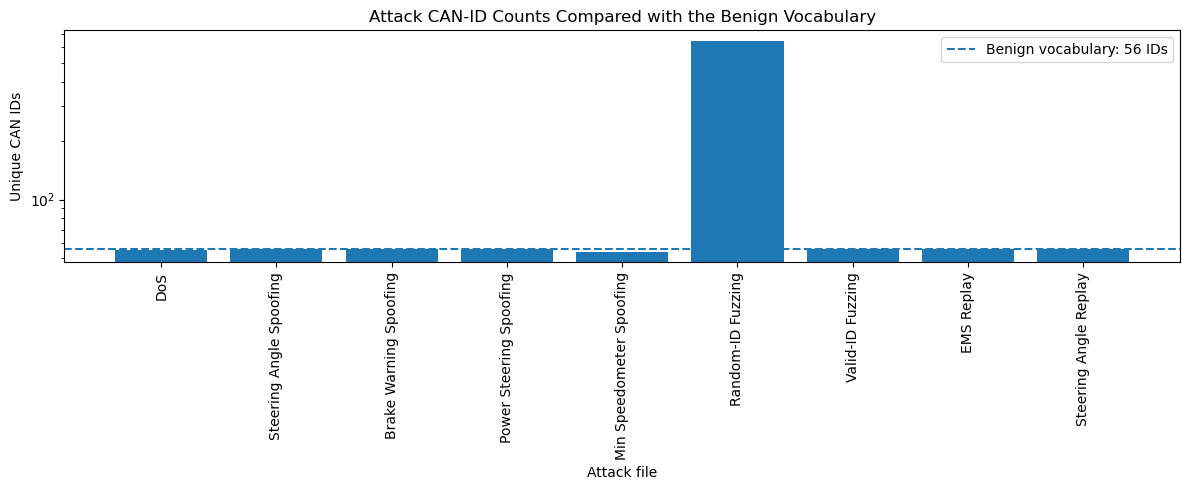

In [12]:
attack_names = []
attack_unique_id_counts = []

for attack_result in attack_results:

    attack_names.append(attack_result["attack"])
    attack_unique_id_counts.append(len(attack_result["complete_file_can_ids"]))

plt.figure(figsize=(12, 5))

plt.bar(attack_names, attack_unique_id_counts)

plt.axhline(y=len(benign_union), linestyle="--", label=f"Benign vocabulary: {len(benign_union)} IDs")

plt.yscale("log")

plt.xlabel("Attack file")
plt.ylabel("Unique CAN IDs")
plt.title("Attack CAN-ID Counts Compared with the Benign Vocabulary")

plt.xticks(rotation=90)

plt.legend()
plt.tight_layout()
plt.show()


Overall, the notebook confirms that CAN ID analysis is useful for validating the dataset and identifying obvious fuzzing behaviour, but it is not sufficient as the main detection method. This supports the use of masked self supervised learning to capture deeper temporal and payload behaviour before performing multiclass classification.